# Tests on APOGEE DR17 and MWM DR19 data to assess how SNR scales with Hmag and exposure time in different Hmag ranges

In [1]:
# load in the correct modules
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import cmasher as cma
import matplotlib.cm as cm
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
from matplotlib.colors import LogNorm

# For APOGEE DR17

In [2]:
# LOAD THE DATA
path = '/Users/dhortad/Documents/Data/dr17_dr3_McMillan_astroNN_rev1.fits'
tb = fits.open(path)
data = tb[1].data 
print(len(data))

733900


In [3]:
# using astroNN distances
mask_hge = data['weighted_dist']>7000
print('There are '+str(len(data[mask_hge]))+' stars within the HGE footprint')

There are 59845 stars within the HGE footprint


In [4]:
Habs = data['H'] - (5.*np.log10(data['weighted_dist'])) +5.

# Signal-to-noise

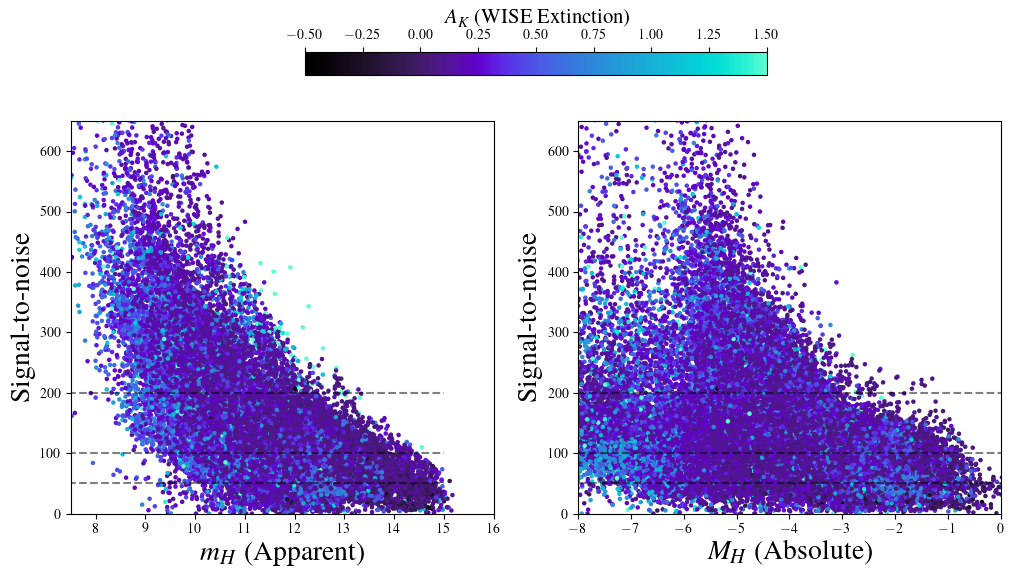

In [6]:

fig = plt.figure(figsize=(12, 6)) # Increased height slightly to accommodate top colorbar

# Subplot 1: Apparent Magnitude
ax1 = plt.subplot(1, 2, 1)
plt.hlines([50, 100, 200], 7, 15, ls='--', color='k', alpha=0.5)
sc = plt.scatter(data['H'][mask_hge], data['SNR'][mask_hge], s=5, 
                 c=data['AK_WISE'][mask_hge], cmap=cma.cosmic, vmin=-0.5, vmax=1.5)
plt.xlabel('$m_H$ (Apparent)', fontsize=20)
plt.ylabel('Signal-to-noise', fontsize=20)
plt.xlim(7.5, 16)
plt.ylim(0, 650)

# Subplot 2: Absolute Magnitude
ax2 = plt.subplot(1, 2, 2)
plt.hlines([50, 100, 200], -8, 0, ls='--', color='k', alpha=0.5)
plt.scatter(Habs[mask_hge], data['SNR'][mask_hge], s=5, 
            c=data['AK_WISE'][mask_hge], cmap=cma.cosmic, vmin=-0.5, vmax=1.5)
plt.xlabel('$M_H$ (Absolute)', fontsize=20)
plt.ylabel('Signal-to-noise', fontsize=20)
plt.xlim(-8, 0)
plt.ylim(0, 650)

# Add colorbar at the top
# orientation='horizontal', location='top' puts it above the plots
cbar = fig.colorbar(sc, ax=[ax1, ax2], orientation='horizontal', 
                    location='top', fraction=0.05, pad=0.1)
cbar.set_label('$A_K$ (WISE Extinction)', fontsize=15)

plt.show()


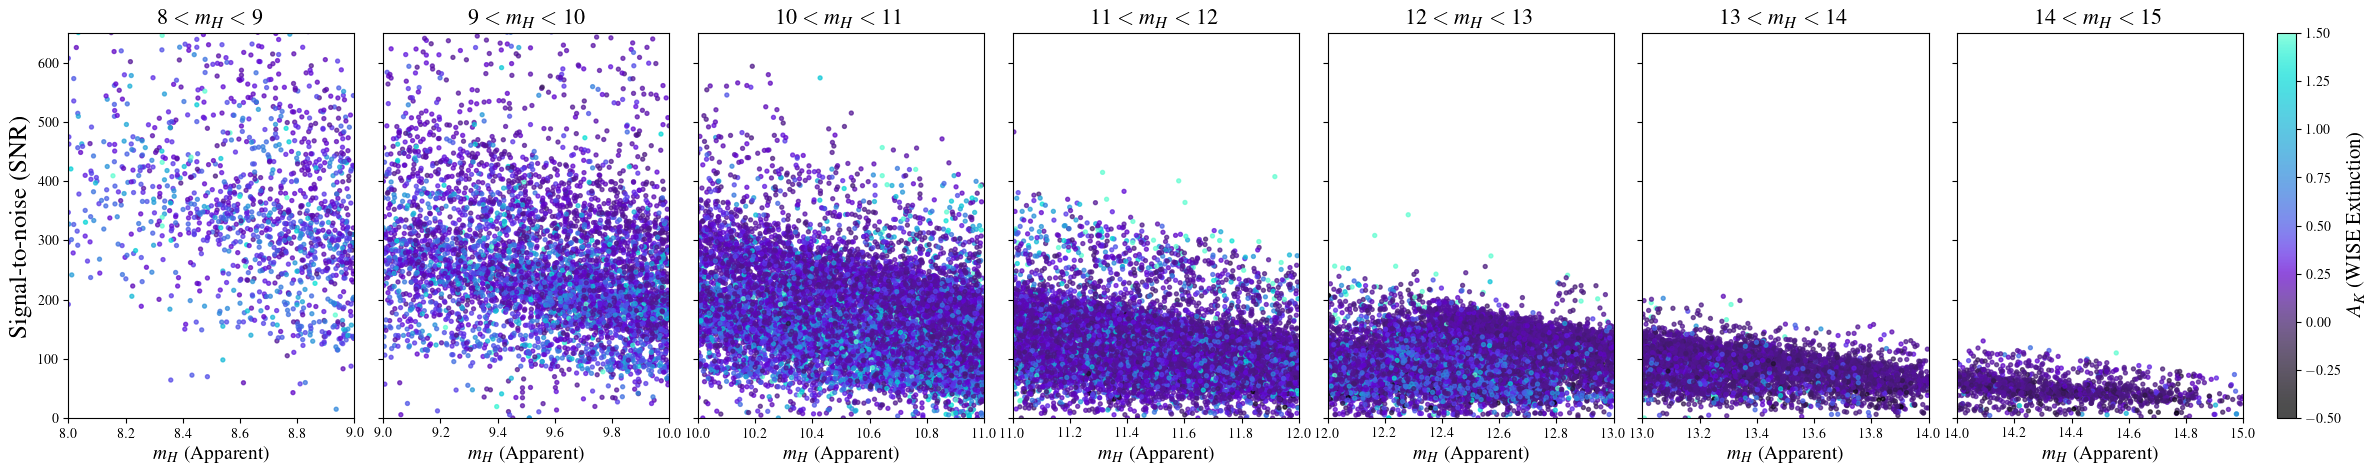

In [7]:
# 1. Define the apparent magnitude bins
# Bright to Faint
mH_bins = [(8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15)]

fig, axes = plt.subplots(1, 7, figsize=(30, 5), sharey=True)

# 2. Iterate through bins to create the grid
for i, (low, high) in enumerate(mH_bins):
    ax = axes[i]
    
    # Create mask for this specific H-mag range
    # Re-using your 'mask_hge' as a base
    mag_mask = (data['H'] >= low) & (data['H'] < high) & mask_hge
    
    # Horizontal SNR reference lines
    ax.hlines([50, 100, 200], -8, 0, ls='--', color='k', alpha=0.3)
    
    # Scatter plot: Absolute Mag vs SNR, colored by Extinction
    sc = ax.scatter(data['H'][mag_mask], data['SNR'][mag_mask], s=8, 
                    c=data['AK_WISE'][mag_mask], cmap=cma.cosmic, 
                    vmin=-0.5, vmax=1.5, alpha=0.7)
    
    # Formatting
    ax.set_title(f'${low} < m_H < {high}$', fontsize=16)
    ax.set_xlabel('$m_H$ (Apparent)', fontsize=14)
    ax.set_xlim(low,high)
    ax.set_ylim(0, 650)
    
    if i == 0:
        ax.set_ylabel('Signal-to-noise (SNR)', fontsize=18)

# 3. Add the colorbar at the top spanning all subplots
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', 
                    location='right', fraction=0.05, pad=0.12)
cbar.set_label('$A_K$ (WISE Extinction)', fontsize=15)

plt.subplots_adjust(wspace=0.1, right=0.85) # Tighten space between subplots
plt.show()

# Exposure time

This page https://www.sdss4.org/dr15/irspec/apogee-observing/ tells me that each APOGEE observation (i.e., visit) consists of 8 exposures, each of which is 500 seconds a piece. Thus, a visit = 8 * 500 seconds.

In [8]:
exptime_seconds = data['NVISITS'] * 8 * 500
exptime_hours = exptime_seconds/3600

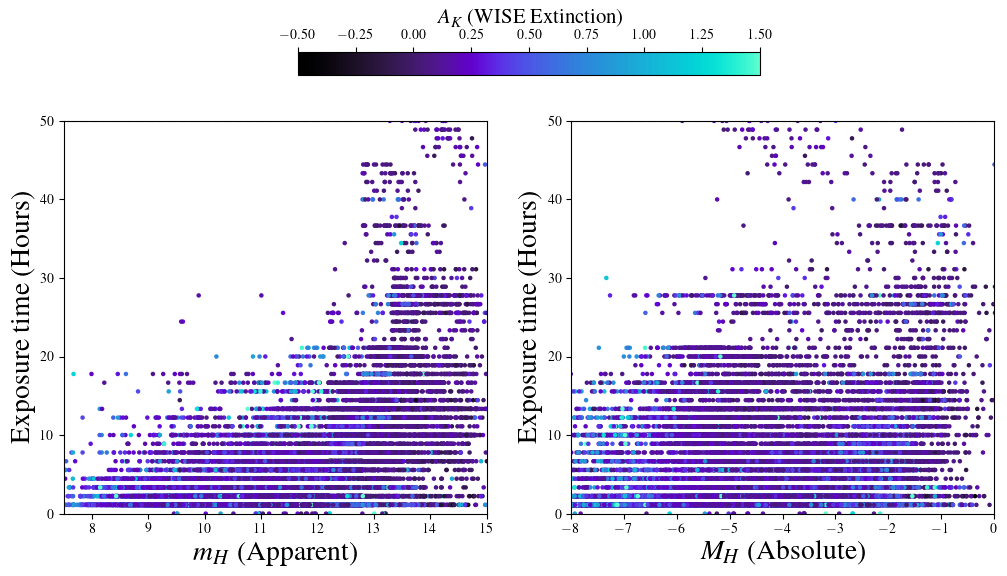

In [14]:
fig = plt.figure(figsize=(12, 6)) # Increased height slightly to accommodate top colorbar

# Subplot 1: Apparent Magnitude
ax1 = plt.subplot(1, 2, 1)
plt.hlines([50, 100, 200], 7, 15, ls='--', color='k', alpha=0.5)
sc = plt.scatter(data['H'][mask_hge], exptime_hours[mask_hge], s=5, 
                 c=data['AK_WISE'][mask_hge], cmap=cma.cosmic, vmin=-0.5, vmax=1.5)
plt.xlabel('$m_H$ (Apparent)', fontsize=20)
plt.ylabel('Exposure time (Hours)', fontsize=20)
plt.xlim(7.5, 15)
plt.ylim(0, 50)

# Subplot 2: Absolute Magnitude
ax2 = plt.subplot(1, 2, 2)
plt.hlines([50, 100, 200], -8, 0, ls='--', color='k', alpha=0.5)
plt.scatter(Habs[mask_hge], exptime_hours[mask_hge], s=5, 
            c=data['AK_WISE'][mask_hge], cmap=cma.cosmic, vmin=-0.5, vmax=1.5)
plt.xlabel('$M_H$ (Absolute)', fontsize=20)
plt.ylabel('Exposure time (Hours)', fontsize=20)
plt.xlim(-8, 0)
plt.ylim(0, 50)

# Add colorbar at the top
# orientation='horizontal', location='top' puts it above the plots
cbar = fig.colorbar(sc, ax=[ax1, ax2], orientation='horizontal', 
                    location='top', fraction=0.05, pad=0.1)
cbar.set_label('$A_K$ (WISE Extinction)', fontsize=15)

plt.show()


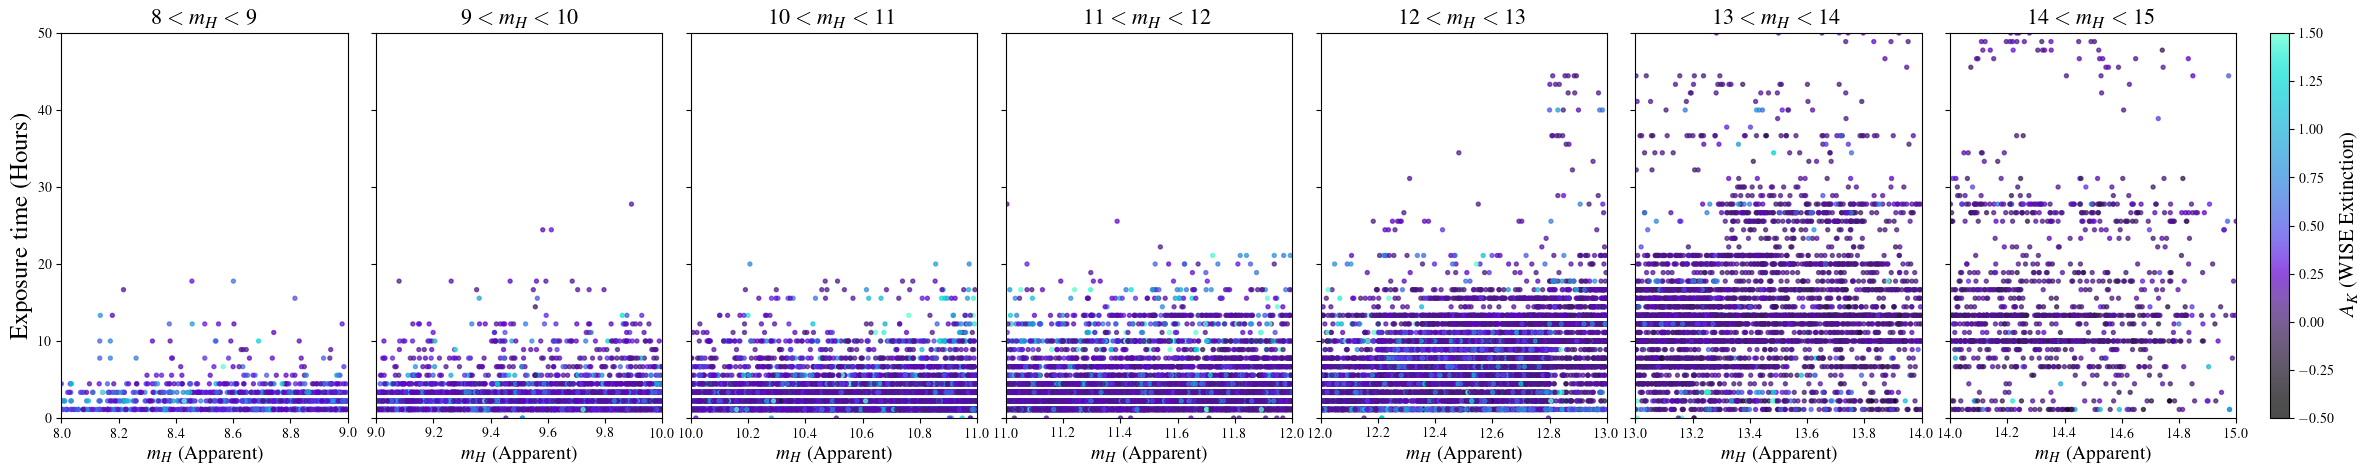

In [15]:
# 1. Define the apparent magnitude bins
# Bright to Faint
mH_bins = [(8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15)]

fig, axes = plt.subplots(1, 7, figsize=(30, 5), sharey=True)

# 2. Iterate through bins to create the grid
for i, (low, high) in enumerate(mH_bins):
    ax = axes[i]
    
    # Create mask for this specific H-mag range
    # Re-using your 'mask_hge' as a base
    mag_mask = (data['H'] >= low) & (data['H'] < high) & mask_hge
    
    # Horizontal SNR reference lines
    ax.hlines([50, 100, 200], -8, 0, ls='--', color='k', alpha=0.3)
    
    # Scatter plot: Absolute Mag vs SNR, colored by Extinction
    sc = ax.scatter(data['H'][mag_mask], exptime_hours[mag_mask], s=8, 
                    c=data['AK_WISE'][mag_mask], cmap=cma.cosmic, 
                    vmin=-0.5, vmax=1.5, alpha=0.7)
    
    # Formatting
    ax.set_title(f'${low} < m_H < {high}$', fontsize=16)
    ax.set_xlabel('$m_H$ (Apparent)', fontsize=14)
    ax.set_xlim(low,high)
    ax.set_ylim(0, 50)
    
    if i == 0:
        ax.set_ylabel('Exposure time (Hours)', fontsize=18)

# 3. Add the colorbar at the top spanning all subplots
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', 
                    location='right', fraction=0.05, pad=0.12)
cbar.set_label('$A_K$ (WISE Extinction)', fontsize=15)

plt.subplots_adjust(wspace=0.1, right=0.85) # Tighten space between subplots
plt.show()

# Exposure time vs SNR for bins of H

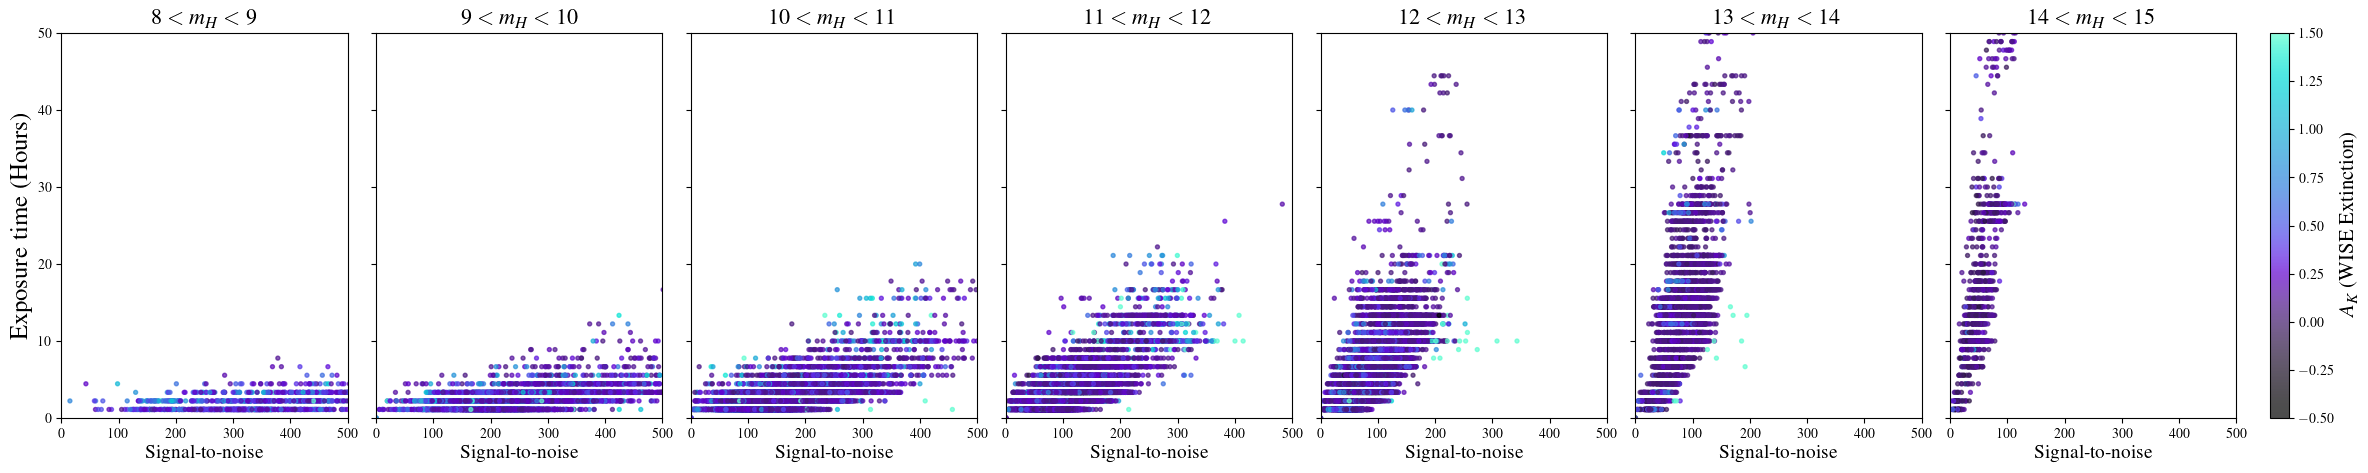

In [16]:
# 1. Define the apparent magnitude bins
# Bright to Faint
mH_bins = [(8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15)]

fig, axes = plt.subplots(1, 7, figsize=(30, 5), sharey=True)

# 2. Iterate through bins to create the grid
for i, (low, high) in enumerate(mH_bins):
    ax = axes[i]
    
    # Create mask for this specific H-mag range
    # Re-using your 'mask_hge' as a base
    mag_mask = (data['H'] >= low) & (data['H'] < high) & mask_hge
    
    # Horizontal SNR reference lines
    ax.hlines([50, 100, 200], -8, 0, ls='--', color='k', alpha=0.3)
    
    # Scatter plot: Absolute Mag vs SNR, colored by Extinction
    sc = ax.scatter(data['SNR'][mag_mask], exptime_hours[mag_mask], s=8, 
                    c=data['AK_WISE'][mag_mask], cmap=cma.cosmic, 
                    vmin=-0.5, vmax=1.5, alpha=0.7)
    
    # Formatting
    ax.set_title(f'${low} < m_H < {high}$', fontsize=16)
    ax.set_xlabel('Signal-to-noise', fontsize=14)
    ax.set_xlim(0,500)
    ax.set_ylim(0, 50)
    
    if i == 0:
        ax.set_ylabel('Exposure time (Hours)', fontsize=18)

# 3. Add the colorbar at the top spanning all subplots
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', 
                    location='right', fraction=0.05, pad=0.12)
cbar.set_label('$A_K$ (WISE Extinction)', fontsize=15)

plt.subplots_adjust(wspace=0.1, right=0.85) # Tighten space between subplots
plt.show()

# Repeat the analysis with DR19

In [17]:
# LOAD THE DATA
path = '/Users/dhortad/Documents/Data/sdssv-mwm-ipl4-apogee-orbits.fits'
tb = fits.open(path)
data = tb[1].data 
print(len(data))

2442693


In [18]:
# using Bailer-Jones photo-geometric distances
mask_hge = data['r_med_photogeo']>7000
print('There are '+str(len(data[mask_hge]))+' stars within the HGE footprint with distances greater than 7 kpc')

There are 201829 stars within the HGE footprint with distances greater than 7 kpc


In [19]:
Habs = data['h_mag'] - (5.*np.log10(data['r_med_photogeo'])) +5.

# Signal-to-noise

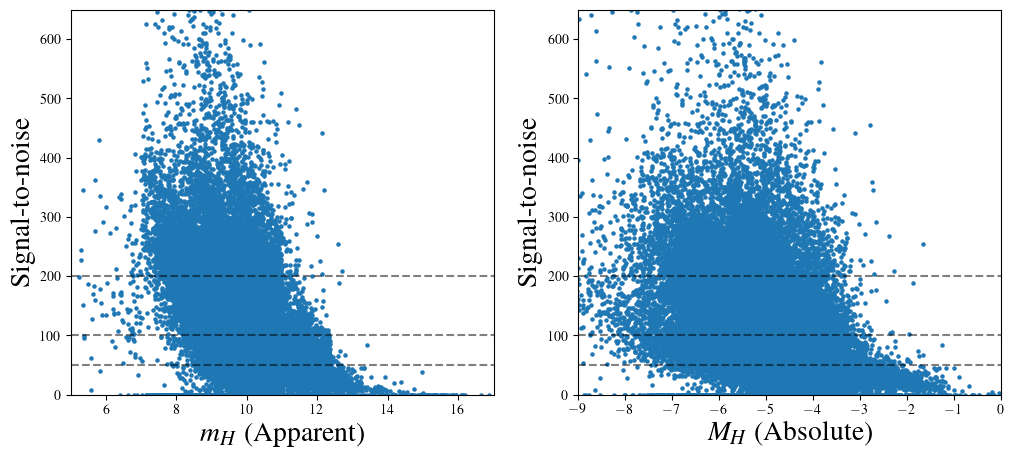

In [22]:

fig = plt.figure(figsize=(12, 5)) # Increased height slightly to accommodate top colorbar

# Subplot 1: Apparent Magnitude
ax1 = plt.subplot(1, 2, 1)
plt.hlines([50, 100, 200], 5, 17, ls='--', color='k', alpha=0.5)
sc = plt.scatter(data['h_mag'][mask_hge], data['snr'][mask_hge], s=5)
plt.xlabel('$m_H$ (Apparent)', fontsize=20)
plt.ylabel('Signal-to-noise', fontsize=20)
plt.xlim(5., 17)
plt.ylim(0, 650)

# Subplot 2: Absolute Magnitude
ax2 = plt.subplot(1, 2, 2)
plt.hlines([50, 100, 200], -9, 0, ls='--', color='k', alpha=0.5)
plt.scatter(Habs[mask_hge], data['snr'][mask_hge], s=5)
            # c=data['ebv'][mask_hge], cmap=cma.cosmic, vmin=-0.5, vmax=1.5)
plt.xlabel('$M_H$ (Absolute)', fontsize=20)
plt.ylabel('Signal-to-noise', fontsize=20)
plt.xlim(-9, 0)
plt.ylim(0, 650)

# Add colorbar at the top
# orientation='horizontal', location='top' puts it above the plots
# cbar = fig.colorbar(sc, ax=[ax1, ax2], orientation='horizontal', 
#                     location='top', fraction=0.05, pad=0.1)
# cbar.set_label('E($B-V$)', fontsize=15)

plt.show()


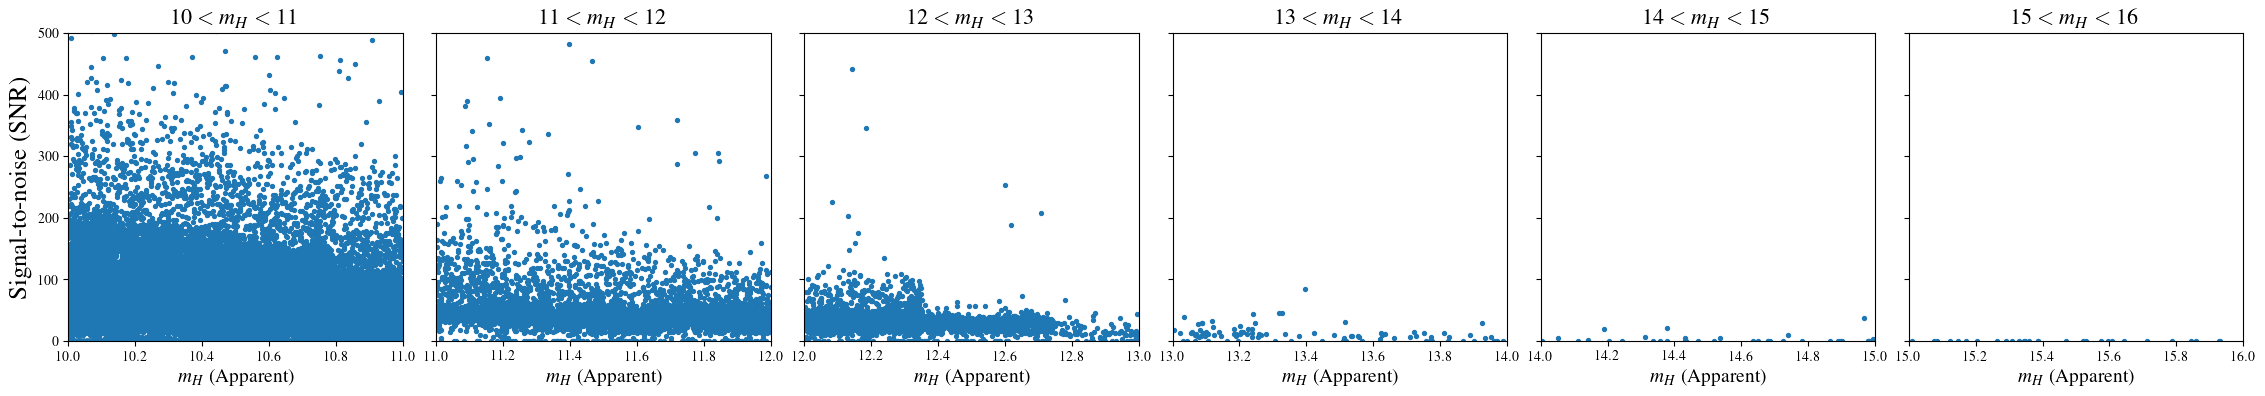

In [23]:
# 1. Define the apparent magnitude bins
# Bright to Faint
mH_bins = [(10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16)]

fig, axes = plt.subplots(1, 6, figsize=(30,4), sharey=True)

# 2. Iterate through bins to create the grid
for i, (low, high) in enumerate(mH_bins):
    ax = axes[i]
    
    # Create mask for this specific H-mag range
    # Re-using your 'mask_hge' as a base
    mag_mask = (data['h_mag'] >= low) & (data['h_mag'] < high) & mask_hge
    
    # Horizontal SNR reference lines
    ax.hlines([50, 100, 200], -8, 0, ls='--', color='k', alpha=0.3)
    
    # Scatter plot: Absolute Mag vs SNR, colored by Extinction
    sc = ax.scatter(data['h_mag'][mag_mask], data['snr'][mag_mask], s=8)
    
    # Formatting
    ax.set_title(f'${low} < m_H < {high}$', fontsize=16)
    ax.set_xlabel('$m_H$ (Apparent)', fontsize=14)
    ax.set_xlim(low,high)
    ax.set_ylim(0, 500)
    
    if i == 0:
        ax.set_ylabel('Signal-to-noise (SNR)', fontsize=18)

# 3. Add the colorbar at the top spanning all subplots
# cbar = fig.colorbar(sc, ax=axes, orientation='vertical', 
#                     location='right', fraction=0.05, pad=0.12)
# cbar.set_label('$A_K$ (WISE Extinction)', fontsize=15)

plt.subplots_adjust(wspace=0.1, right=0.85) # Tighten space between subplots
plt.show()

# Exposure time

In [24]:
exptime_seconds = data['n_visits'] * 8 * 500
exptime_hours = exptime_seconds/3600

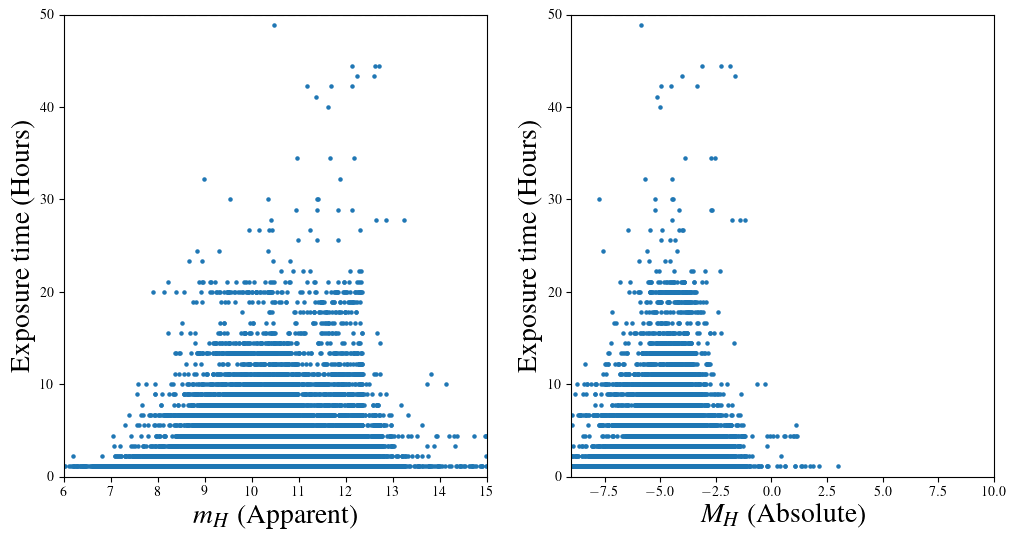

In [26]:
fig = plt.figure(figsize=(12, 6)) # Increased height slightly to accommodate top colorbar

# Subplot 1: Apparent Magnitude
ax1 = plt.subplot(1, 2, 1)
plt.hlines([50, 100, 200], 7, 17, ls='--', color='k', alpha=0.5)
sc = plt.scatter(data['h_mag'][mask_hge], exptime_hours[mask_hge], s=5)
plt.xlabel('$m_H$ (Apparent)', fontsize=20)
plt.ylabel('Exposure time (Hours)', fontsize=20)
plt.xlim(6, 15)
plt.ylim(0, 50)

# Subplot 2: Absolute Magnitude
ax2 = plt.subplot(1, 2, 2)
plt.hlines([50, 100, 200], -8, 0, ls='--', color='k', alpha=0.5)
plt.scatter(Habs[mask_hge], exptime_hours[mask_hge], s=5)
plt.xlabel('$M_H$ (Absolute)', fontsize=20)
plt.ylabel('Exposure time (Hours)', fontsize=20)
plt.xlim(-9, 10)
plt.ylim(0, 50)

# Add colorbar at the top
# orientation='horizontal', location='top' puts it above the plots
# cbar = fig.colorbar(sc, ax=[ax1, ax2], orientation='horizontal', 
#                     location='top', fraction=0.05, pad=0.1)
# cbar.set_label('$A_K$ (WISE Extinction)', fontsize=15)

plt.show()


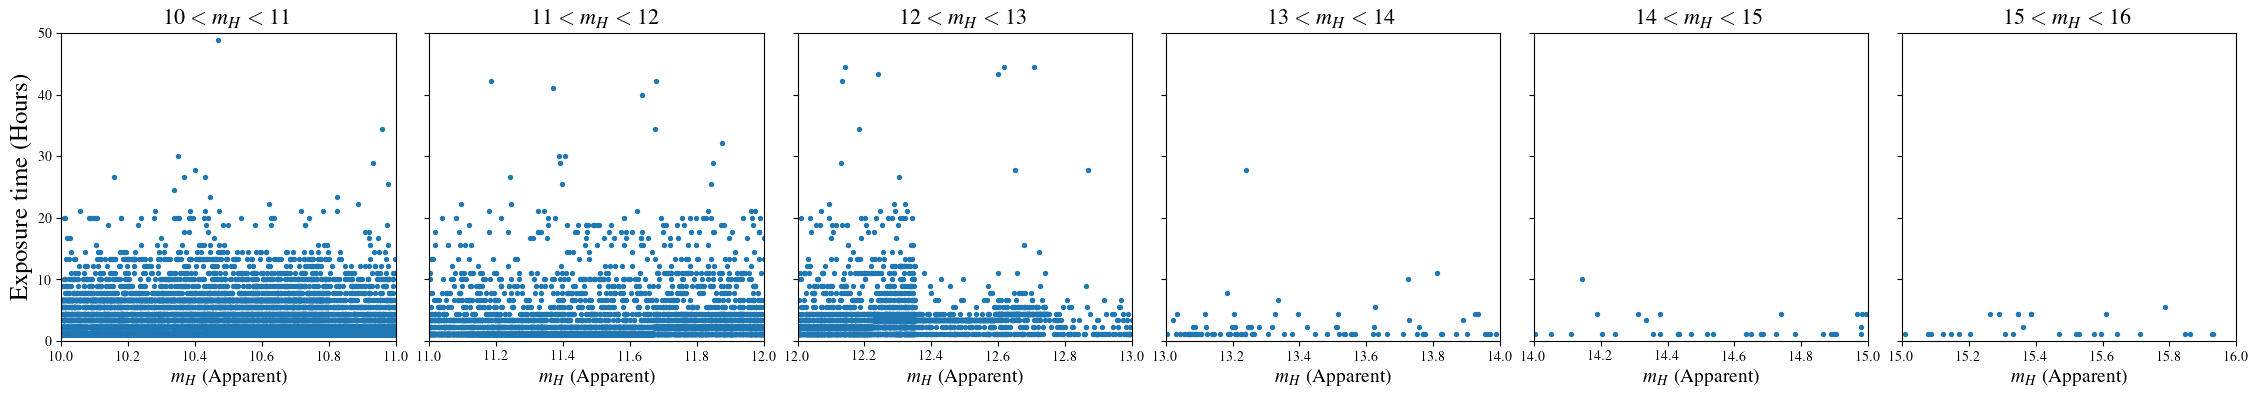

In [27]:
# 1. Define the apparent magnitude bins
# Bright to Faint
mH_bins = [(10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16)]

fig, axes = plt.subplots(1, 6, figsize=(30, 4), sharey=True)

# 2. Iterate through bins to create the grid
for i, (low, high) in enumerate(mH_bins):
    ax = axes[i]
    
    # Create mask for this specific H-mag range
    # Re-using your 'mask_hge' as a base
    mag_mask = (data['h_mag'] >= low) & (data['h_mag'] < high) & mask_hge
    
    # Horizontal SNR reference lines
    ax.hlines([50, 100, 200], -8, 0, ls='--', color='k', alpha=0.3)
    
    # Scatter plot: Absolute Mag vs SNR, colored by Extinction
    sc = ax.scatter(data['h_mag'][mag_mask], exptime_hours[mag_mask], s=8)
    
    # Formatting
    ax.set_title(f'${low} < m_H < {high}$', fontsize=16)
    ax.set_xlabel('$m_H$ (Apparent)', fontsize=14)
    ax.set_xlim(low,high)
    ax.set_ylim(0, 50) 
    
    if i == 0:
        ax.set_ylabel('Exposure time (Hours)', fontsize=18)

# 3. Add the colorbar at the top spanning all subplots
# cbar = fig.colorbar(sc, ax=axes, orientation='vertical', 
#                     location='right', fraction=0.05, pad=0.12)
# cbar.set_label('$A_K$ (WISE Extinction)', fontsize=15)

plt.subplots_adjust(wspace=0.1, right=0.85) # Tighten space between subplots
plt.show()

# Exposure time vs Signal-to-noise in bins of H

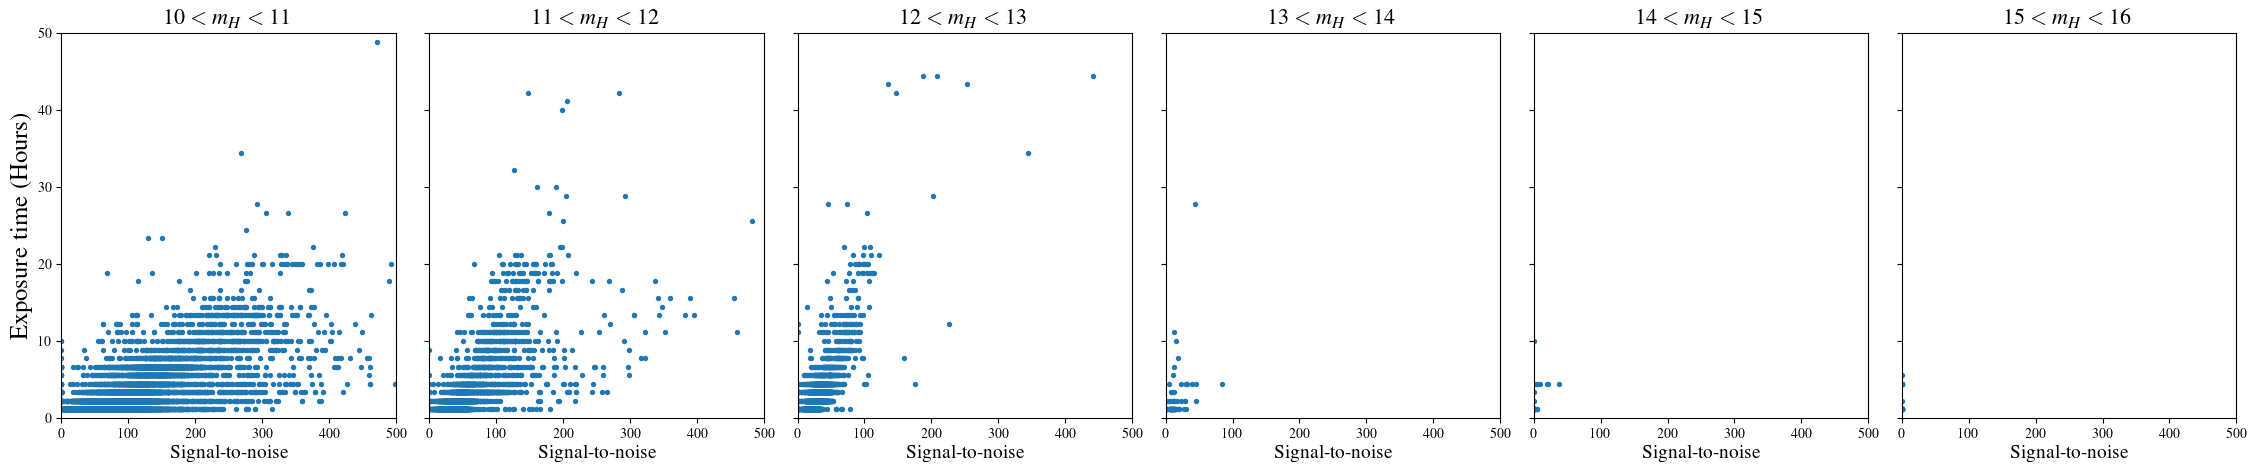

In [28]:
# 1. Define the apparent magnitude bins
# Bright to Faint
mH_bins = [(10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16)]

fig, axes = plt.subplots(1, 6, figsize=(30, 5), sharey=True)

# 2. Iterate through bins to create the grid
for i, (low, high) in enumerate(mH_bins):
    ax = axes[i]
    
    # Create mask for this specific H-mag range
    # Re-using your 'mask_hge' as a base
    mag_mask = (data['h_mag'] >= low) & (data['h_mag'] < high) & mask_hge
    
    # Horizontal SNR reference lines
    ax.hlines([50, 100, 200], -8, 0, ls='--', color='k', alpha=0.3)
    
    # Scatter plot: Absolute Mag vs SNR, colored by Extinction
    sc = ax.scatter(data['snr'][mag_mask], exptime_hours[mag_mask], s=8)
    
    # Formatting
    ax.set_title(f'${low} < m_H < {high}$', fontsize=16)
    ax.set_xlabel('Signal-to-noise', fontsize=14)
    ax.set_xlim(0,500)
    ax.set_ylim(0, 50)
    
    if i == 0:
        ax.set_ylabel('Exposure time (Hours)', fontsize=18)

# 3. Add the colorbar at the top spanning all subplots
# cbar = fig.colorbar(sc, ax=axes, orientation='vertical', 
#                     location='right', fraction=0.05, pad=0.12)
# cbar.set_label('$A_K$ (WISE Extinction)', fontsize=15)

plt.subplots_adjust(wspace=0.1, right=0.85) # Tighten space between subplots
plt.show()